In [ ]:
# Cell 1: Install dependencies
!pip install -qU langgraph langchain-google-genai pydantic


🗺️  Multi-Agent Architecture:



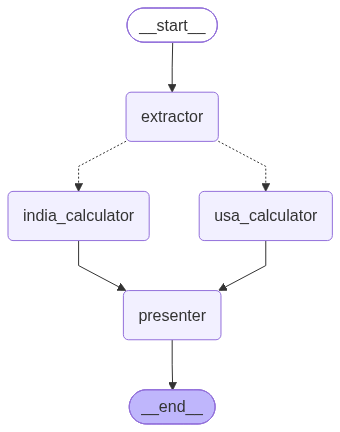


╔══════════════════════════════════════════════════════════╗
║     Multi-Agent Tax Calculator (LangGraph Demo)          ║
║                                                          ║
║  Agents:                                                 ║
║   1. Extractor Agent                                     ║
║   2. Orchestrator / Router                               ║
║   3. USA Calculator Agent (2026 rules)                   ║
║   4. India Calculator Agent (New Regime)                 ║
║   5. Presenter Agent                                     ║
║                                                          ║
║  Just type naturally. Examples:                          ║
║  • "Single, USA, income $115000, IRA $6500"              ║
║  • "India salary 18 lakh new regime"                     ║
║                                                          ║
║  Type 'exit' to quit                                     ║
╚══════════════════════════════════════════════════════════╝


💬 Enter your tax deta

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


📌 [Orchestrator] Routing to → USA Calculator
→ Completed: extractor
📌 [USA Calculator Agent] Computing federal tax (2026 rules)...
→ Completed: usa_calculator
📌 [Presenter Agent] Generating final report...
→ Completed: presenter
📌 [Extractor Agent] Analyzing user input...


/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


📌 [Orchestrator] Routing to → USA Calculator
📌 [USA Calculator Agent] Computing federal tax (2026 rules)...
📌 [Presenter Agent] Generating final report...

⏱  Total pipeline time: 12.98s

╔════════════════════════════════════════════════════════════╗
║           📊  TAX BREAKDOWN REPORT                         ║
╠════════════════════════════════════════════════════════════╣
║  Country        : USA                                      ║
║  Tax Year       : 2026                                     ║
║  Filing Status  : Single                                   ║
╠════════════════════════════════════════════════════════════╣
║  Gross Income           $     115,000.00          ║
║  Adjusted / Base        $     106,000.00          ║
║  Standard Deduction     $      16,100.00          ║
║  Taxable Income         $      89,900.00          ║
╠════════════════════════════════════════════════════════════╣
║  💰 TOTAL TAX OWED      $      14,490.00          ║
║  Effective Rate                  12.60

In [ ]:
# ============================================================
# Multi-Agent Tax Calculator with LangGraph (Interactive Demo)
# Supports: USA 2026 + India New Regime (FY 2025-26)
# ============================================================

import time
from typing import Literal, TypedDict, Annotated, Optional
from pydantic import BaseModel, Field
from google.colab import userdata

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from IPython.display import Image, display

# ------------------------------------------------------------
# 1. LLM Setup
# ------------------------------------------------------------
api_key = userdata.get('GEMINI_API_KEY')

llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    google_api_key=api_key,
    temperature=0
)

# ------------------------------------------------------------
# 2. Shared State
# ------------------------------------------------------------
class TaxState(TypedDict):
    messages: Annotated[list, add_messages]
    country: Optional[str]
    extracted: Optional[dict]
    calculation: Optional[dict]
    final_report: Optional[str]

# ------------------------------------------------------------
# 3. Structured Extraction Schema
# ------------------------------------------------------------
class ExtractedTaxData(BaseModel):
    country: Literal["USA", "India"] = Field(description="USA or India")
    filing_status: str = Field(description="USA: Single/Married Filing Jointly/Head of Household | India: Individual")
    gross_income: float = Field(description="Total gross income / salary")
    ira_contribution: float = Field(default=0.0)
    student_loan_interest: float = Field(default=0.0)
    charitable_contributions: float = Field(default=0.0)
    other_deductions: float = Field(default=0.0, description="For India")

extractor_llm = llm.with_structured_output(ExtractedTaxData)

# ------------------------------------------------------------
# 4. Agent Nodes
# ------------------------------------------------------------

def extractor_agent(state: TaxState):
    """Agent 1: Extracts structured tax data from natural language"""
    print("📌 [Extractor Agent] Analyzing user input...")

    user_msg = state["messages"][-1].content
    extracted = extractor_llm.invoke(
        f"Extract tax information carefully. Infer country as USA or India.\n\nUser: {user_msg}"
    )

    return {
        "extracted": extracted.model_dump(),
        "country": extracted.country,
        "messages": [AIMessage(content=f"✅ Extracted data for {extracted.country}")]
    }

def router(state: TaxState) -> Literal["usa_calculator", "india_calculator", "ghana_calculator", "fallback"]:
    """Orchestration layer – decides which calculator (or fallback) to call"""
    country = (state.get("country") or "").upper().strip()

    print(f"📌 [Orchestrator] Detected country: {country or 'Unknown'}")

    if country == "USA":
        print("📌 [Orchestrator] Routing to → USA Calculator")
        return "usa_calculator"
    elif country == "INDIA":
        print("📌 [Orchestrator] Routing to → India Calculator")
        return "india_calculator"
    elif country == "GHANA":
        print("📌 [Orchestrator] Routing to → Ghana Calculator")
        return "ghana_calculator"
    else:
        print("📌 [Orchestrator] Routing to → Fallback (Unsupported)")
        return "fallback"

def usa_calculator_agent(state: TaxState):
    """Agent 2a: USA 2026 Tax Calculator (deterministic)"""
    print("📌 [USA Calculator Agent] Computing federal tax (2026 rules)...")

    data = state["extracted"]
    status = data["filing_status"].title().replace("Of", "of")

    ira_ded = min(data.get("ira_contribution", 0), 7000)
    student_ded = min(data.get("student_loan_interest", 0), 2500)
    agi = max(0, data["gross_income"] - ira_ded - student_ded)

    std_map = {
        "Single": 16100,
        "Married Filing Jointly": 32200,
        "Head of Household": 24150
    }
    std_ded = std_map.get(status, 16100)
    taxable = max(0, agi - std_ded)

    if status == "Married Filing Jointly":
        brackets = [(24800, 0.10), (100800, 0.12), (211400, 0.22),
                    (403550, 0.24), (512450, 0.32), (768700, 0.35), (float('inf'), 0.37)]
    elif status == "Head of Household":
        brackets = [(17700, 0.10), (67450, 0.12), (105700, 0.22),
                    (201750, 0.24), (256200, 0.32), (640600, 0.35), (float('inf'), 0.37)]
    else:
        brackets = [(12400, 0.10), (50400, 0.12), (105700, 0.22),
                    (201775, 0.24), (256225, 0.32), (640600, 0.35), (float('inf'), 0.37)]

    tax = 0.0
    prev = 0.0
    for limit, rate in brackets:
        if taxable > prev:
            tax += (min(taxable, limit) - prev) * rate
            prev = limit
        else:
            break

    result = {
        "country": "USA",
        "year": "2026",
        "agi": agi,
        "std_ded": std_ded,
        "taxable": taxable,
        "tax_owed": tax,
        "effective_rate": (tax / data["gross_income"] * 100) if data["gross_income"] else 0,
        "currency": "USD"
    }

    return {
        "calculation": result,
        "messages": [AIMessage(content="✅ USA tax calculated successfully")]
    }

def india_calculator_agent(state: TaxState):
    """Agent 2b: India New Regime Calculator (FY 2025-26)"""
    print("📌 [India Calculator Agent] Computing tax under New Regime...")

    data = state["extracted"]
    std_ded = 75000
    taxable = max(0, data["gross_income"] - std_ded - data.get("other_deductions", 0))

    brackets = [
        (400000, 0.00), (800000, 0.05), (1200000, 0.10),
        (1600000, 0.15), (2000000, 0.20), (2400000, 0.25),
        (float('inf'), 0.30)
    ]

    tax = 0.0
    prev = 0.0
    for limit, rate in brackets:
        if taxable > prev:
            tax += (min(taxable, limit) - prev) * rate
            prev = limit
        else:
            break

    if taxable <= 1200000:
        tax = max(0, tax - 60000)

    cess = tax * 0.04
    total = tax + cess

    result = {
        "country": "India",
        "year": "FY 2025-26 (AY 2026-27)",
        "agi": data["gross_income"],
        "std_ded": std_ded,
        "taxable": taxable,
        "tax_owed": total,
        "effective_rate": (total / data["gross_income"] * 100) if data["gross_income"] else 0,
        "currency": "INR",
        "note": "New Regime + 4% cess. 87A rebate applied if eligible."
    }

    return {
        "calculation": result,
        "messages": [AIMessage(content="✅ India tax calculated successfully")]
    }

def presenter_agent(state: TaxState):
    """Agent 3: Creates a beautiful final report"""
    print("📌 [Presenter Agent] Generating final report...")

    # If fallback already created a report, just pass it through
    if state.get("final_report") and state.get("calculation") is None:
        return {
            "final_report": state["final_report"],
            "messages": [AIMessage(content=state["final_report"])]
        }

    calc = state["calculation"]
    extracted = state["extracted"]
    symbol = "$" if calc["currency"] == "USD" else "₹"

    report = f"""
╔════════════════════════════════════════════════════════════╗
║           📊  TAX BREAKDOWN REPORT                         ║
╠════════════════════════════════════════════════════════════╣
║  Country        : {calc['country']:<40} ║
║  Tax Year       : {calc['year']:<40} ║
║  Filing Status  : {extracted['filing_status']:<40} ║
╠════════════════════════════════════════════════════════════╣
║  Gross Income           {symbol}{extracted['gross_income']:>15,.2f}          ║
║  Adjusted / Base        {symbol}{calc['agi']:>15,.2f}          ║
║  Standard Deduction     {symbol}{calc['std_ded']:>15,.2f}          ║
║  Taxable Income         {symbol}{calc['taxable']:>15,.2f}          ║
╠════════════════════════════════════════════════════════════╣
║  💰 TOTAL TAX OWED      {symbol}{calc['tax_owed']:>15,.2f}          ║
║  Effective Rate         {calc['effective_rate']:>14.2f}%          ║
╚════════════════════════════════════════════════════════════╝
"""
    if "note" in calc:
        report += f"\nNote: {calc['note']}\n"

    return {
        "final_report": report,
        "messages": [AIMessage(content=report)]
    }
def fallback_agent(state: TaxState):
    """Fallback Agent – Handles unsupported or invalid scenarios"""
    print("📌 [Fallback Agent] Handling unsupported scenario...")

    detected_country = state.get("country") or "Unknown"
    user_message = state["messages"][-1].content if state.get("messages") else ""

    report = f"""
╔════════════════════════════════════════════════════════════╗
║           ⚠️  UNSUPPORTED SCENARIO DETECTED                ║
╠════════════════════════════════════════════════════════════╣
║  Detected Country : {detected_country:<40} ║
║                                                            ║
║  Currently Supported Countries:                            ║
║    • USA          (Tax Year 2026)                          ║
║    • India        (New Regime – FY 2025-26)                ║
║    • Ghana        (PAYE rates)                             ║
║                                                            ║
║  Your input could not be routed to a specialist agent.     ║
║                                                            ║
║  Suggestions:                                              ║
║    1. Clearly mention the country (e.g. "USA", "India")    ║
║    2. Provide income and filing status                     ║
║    3. Ask the developer to add support for new countries   ║
╚════════════════════════════════════════════════════════════╝
"""

    return {
        "final_report": report,
        "calculation": None,
        "messages": [AIMessage(content=report)]
    }
# ------------------------------------------------------------
# 5. Build the Graph (Orchestration Layer)
# ------------------------------------------------------------
workflow = StateGraph(TaxState)
# Add the new node
workflow.add_node("fallback", fallback_agent)

# Update the conditional edges
workflow.add_conditional_edges(
    "extractor",
    router,
    {
        "usa_calculator": "usa_calculator",
        "india_calculator": "india_calculator",
        "ghana_calculator": "ghana_calculator",
        "fallback": "fallback"
    }
)

# Fallback also goes to Presenter (or directly to END)
workflow.add_edge("fallback", "presenter")   # or END if you prefer

workflow.add_node("extractor", extractor_agent)
workflow.add_node("usa_calculator", usa_calculator_agent)
workflow.add_node("india_calculator", india_calculator_agent)
workflow.add_node("presenter", presenter_agent)

workflow.add_edge(START, "extractor")
workflow.add_conditional_edges("extractor", router, {
    "usa_calculator": "usa_calculator",
    "india_calculator": "india_calculator"
})
workflow.add_edge("usa_calculator", "presenter")
workflow.add_edge("india_calculator", "presenter")
workflow.add_edge("presenter", END)

tax_graph = workflow.compile()

# ------------------------------------------------------------
# 6. Visualize the Graph (great for demos)
# ------------------------------------------------------------
print("\n🗺️  Multi-Agent Architecture:\n")
try:
    display(Image(tax_graph.get_graph().draw_mermaid_png()))
except Exception:
    print("Flow: START → Extractor → Router → (USA / India Calculator) → Presenter → END")

# ------------------------------------------------------------
# 7. Interactive Runner
# ------------------------------------------------------------
def run_tax_pipeline(user_input: str):
    print("\n" + "="*60)
    print("🚀 Starting Multi-Agent Tax Pipeline...")
    print("="*60 + "\n")

    start = time.time()
    inputs = {"messages": [HumanMessage(content=user_input)]}

    # Stream so audience can see each agent
    for step in tax_graph.stream(inputs, stream_mode="updates"):
        for node_name, _ in step.items():
            print(f"→ Completed: {node_name}")

    final_state = tax_graph.invoke(inputs)
    elapsed = time.time() - start

    print(f"\n⏱  Total pipeline time: {elapsed:.2f}s")
    print(final_state["final_report"])

# ------------------------------------------------------------
# 8. Interactive Loop (User Input)
# ------------------------------------------------------------
if __name__ == "__main__":
    print("""
╔══════════════════════════════════════════════════════════╗
║     Multi-Agent Tax Calculator (LangGraph Demo)          ║
║                                                          ║
║  Agents:                                                 ║
║   1. Extractor Agent                                     ║
║   2. Orchestrator / Router                               ║
║   3. USA Calculator Agent (2026 rules)                   ║
║   4. India Calculator Agent (New Regime)                 ║
║   5. Presenter Agent                                     ║
║                                                          ║
║  Just type naturally. Examples:                          ║
║  • "Single, USA, income $115000, IRA $6500"              ║
║  • "India salary 18 lakh new regime"                     ║
║                                                          ║
║  Type 'exit' to quit                                     ║
╚══════════════════════════════════════════════════════════╝
""")

    while True:
        user_input = input("\n💬 Enter your tax details: ").strip()

        if user_input.lower() in ["exit", "quit", "q"]:
            print("\n👋 Demo ended. Thanks!")
            break

        if user_input:
            try:
                run_tax_pipeline(user_input)
            except Exception as e:
                print(f"\n❌ Error: {e}")
                print("Please try again with clearer details.")